<a href="https://colab.research.google.com/github/tayviss/Tayvis_INFO4670_Fall2026/blob/main/INFO4670_Week3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

NAVY = "#22303A"
RUST = "#C0562F"

students = pd.read_csv("student_records.csv")
weekly   = pd.read_csv("weekly_activity.csv")

students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


#One quantitative variable

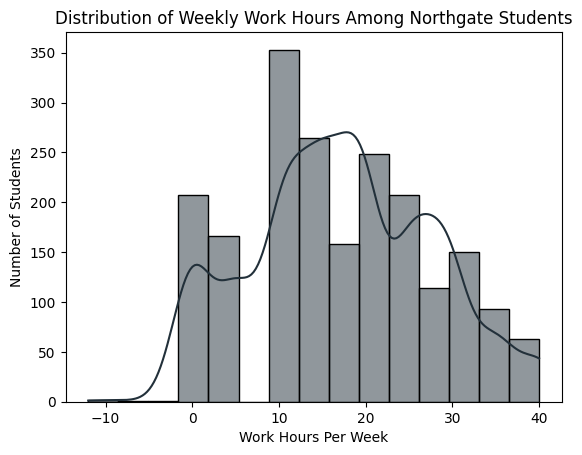

In [2]:
fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", bins=15, color=NAVY, kde=True, ax=ax)
ax.set_title("Distribution of Weekly Work Hours Among Northgate Students")
ax.set_xlabel("Work Hours Per Week")
ax.set_ylabel("Number of Students")
plt.show()

This chart shows how many hours students work each week. I wanted to see how much people work and if someone works too much. Most students work about 15 to 20 hours a week. A few people work more hours, about 35 hours a week. This will show if working more hours impact school grades.

# One categorical variable

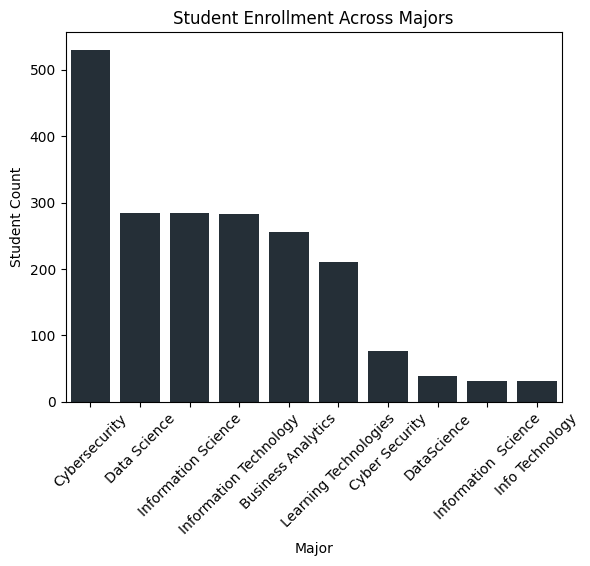

In [3]:
fig, ax = plt.subplots()
order = students['major'].value_counts().index
sns.countplot(data=students, x="major", order=order, color=NAVY, ax=ax)
ax.set_title("Student Enrollment Across Majors")
ax.set_xlabel("Major")
ax.set_ylabel("Student Count")
plt.xticks(rotation=45)
plt.show()

This  chart shows how many students are in each major. I wanted to see what majors have the most people. Computer Science and IT have alot more students than other majors. After the first 3 majors, the amount of students in each major drop alot.

# A quantity, split by category

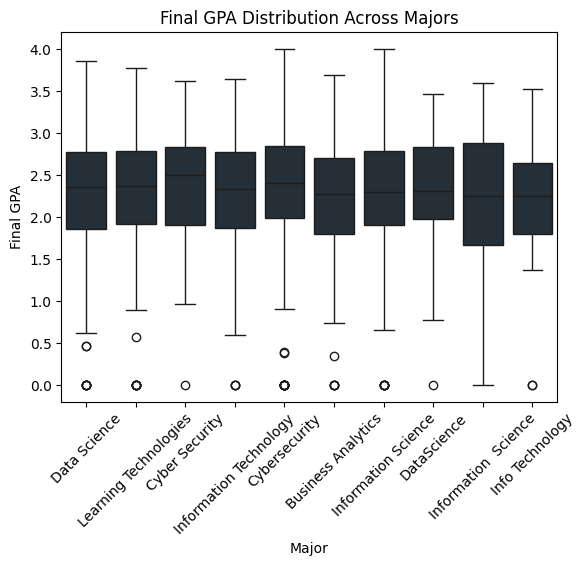

In [4]:
fig, ax = plt.subplots()
sns.boxplot(data=students, x="major", y="final_gpa", color=NAVY, ax=ax)
ax.set_title("Final GPA Distribution Across Majors")
ax.set_xlabel("Major")
ax.set_ylabel("Final GPA")
plt.xticks(rotation=45)
plt.show()

This plot compares final GPA across different majors. I wanted to see if some majors get better grades than others. Most majors have a middle GPA around 3.0, but some majors vary in grades. There are also a few random dots at the bottom for students with the super low GPAs.

# Two quantitative variables

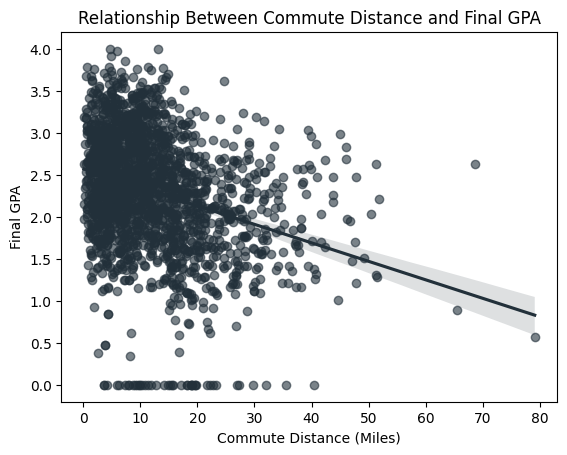

In [5]:
fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa", color=NAVY, scatter_kws={'alpha': 0.6}, ax=ax)
ax.set_title("Relationship Between Commute Distance and Final GPA")
ax.set_xlabel("Commute Distance (Miles)")
ax.set_ylabel("Final GPA")
plt.show()

This plot looks at commute miles versus final GPA. I wanted to see if driving far makes your grades worse. The red line goes down a bit, but the dots are scattered. Some people with 35 mile drives still get 4.0s. Therefore, driving far would not be a factor

# Over time

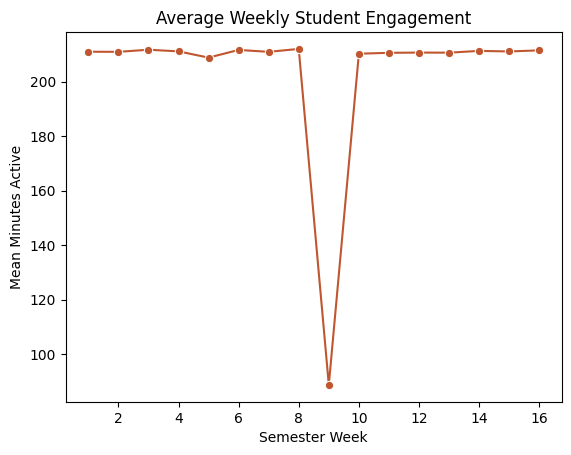

In [6]:
weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()

fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active", color=RUST, marker="o", ax=ax)
ax.set_title("Average Weekly Student Engagement")
ax.set_xlabel("Semester Week")
ax.set_ylabel("Mean Minutes Active")
plt.show()

This graph shows average weekly active minutes on the course site across the semester. Activity starts high, spikes around midterms, dops beacuse of break and then stays steady.

# Your own question

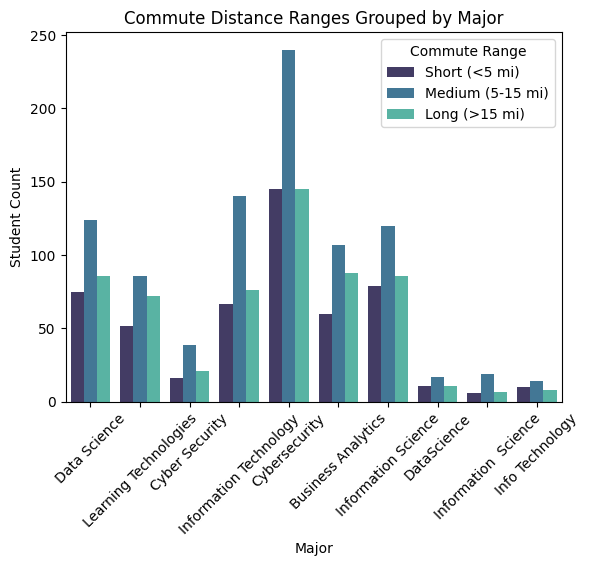

In [7]:
students["commute_range"] = pd.cut(
    students["commute_miles"],
    bins=[-1, 5, 15, 100],
    labels=["Short (<5 mi)", "Medium (5-15 mi)", "Long (>15 mi)"]
)

fig, ax = plt.subplots()
sns.countplot(data=students, x="major", hue="commute_range", palette="mako", ax=ax)
ax.set_title("Commute Distance Ranges Grouped by Major")
ax.set_xlabel("Major")
ax.set_ylabel("Student Count")
ax.legend(title="Commute Range")
plt.xticks(rotation=45)
plt.show()

This chart looks at commute distance ranges for students in different majors. Some majors like IT have more long distance commuters driving over 15 miles. Not many people in more basic majors live close under 5 miles.